## **Exploratory Data Analysis (EDA) & Missing Value**


---
## Import Library & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False
    print('pip install missingno') # download di terminal ygy

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)


pip install missingno


---
## Load Data

In [2]:
PATH_POLUSI = r'c:\Users\User\Air Pollution - Daming Project\data\merged data polusi\polusi_merged.csv'
PATH_CUACA  = r'c:\Users\User\Air Pollution - Daming Project\data\data cuaca\cuaca_merged.csv'

df_polusi = pd.read_csv(PATH_POLUSI)

# Struktur: "-6.19466, 106.8235,1/1/2022,32.3,25,28.6,37.6,25,31.9,24,77.2,0.496,100,8.33,..."
# ini maksudnya part[0]=-lat, part[1]=lon, part[2]=date, part[3]=tempmax, part[4]=tempmin, ...

df_cuaca = pd.read_csv(PATH_CUACA)
df_cuaca['datetime'] = pd.to_datetime(df_cuaca['datetime'])

# cleaning station polusi
df_polusi['station'] = (
    df_polusi['station']
    .str.replace(' CSV', '', regex=False)
    .str.strip()
    .str.lower()
)

# cleaning station cuaca
df_cuaca['station'] = (
    df_cuaca['station']
    .str.strip()
    .str.lower()
)

print('DATA POLUSI')
print(df_polusi['station'].unique())
print(f'Shape : {df_polusi.shape[0]:,} baris × {df_polusi.shape[1]} kolom')
print(f'Kolom : {list(df_polusi.columns)}')
print(f'Tanggal range: {df_polusi["tanggal"].min()} s/d {df_polusi["tanggal"].max()}')

print('\nDATA CUACA')
print(df_cuaca['station'].unique())
print(f'Shape : {df_cuaca.shape[0]:,} baris × {df_cuaca.shape[1]} kolom')

print(f'Tanggal range: {df_cuaca["datetime"].min()} s/d {df_cuaca["datetime"].max()}')

print('\nSample data cuaca:')
display(
    df_cuaca[['datetime', 'station', 'tempmax', 'temp', 'humidity', 'precip']].head(3)
)

DATA POLUSI
<StringArray>
[  'bundaran hi',     'jagakarsa',   'jakarta gbk',   'kebun jeruk',
 'kelapa gading',  'lubang buaya',  'us embassy 1',  'us embassy 2']
Length: 8, dtype: str
Shape : 210,624 baris × 17 kolom
Kolom : ['Waktu', 'ISPU PM10', 'ISPU PM2.5', 'ISPU SO2', 'ISPU CO', 'ISPU O3', 'ISPU NO2', 'Status By PM10', 'Status By PM2.5', 'Status By SO2', 'Status By CO', 'Status By O3', 'Status By NO2', 'Critical Parameter', 'Overall ISPU Status', 'tanggal', 'station']
Tanggal range: 2022-01-01 s/d 2025-01-01

DATA CUACA
<StringArray>
[  'bundaran hi',     'jagakarsa',   'jakarta gbk',   'kebun jeruk',
 'kelapa gading',  'lubang buaya',  'us embassy 1',  'us embassy 2']
Length: 8, dtype: str
Shape : 8,768 baris × 34 kolom
Tanggal range: 2022-01-01 00:00:00 s/d 2024-12-31 00:00:00

Sample data cuaca:


,datetime,station,tempmax,temp,humidity,precip
0,2022-01-01,bundaran hi,32.300,28.600,77.200,0.496
1,2022-01-02,bundaran hi,32.800,28.100,79.200,0.000
2,2022-01-03,bundaran hi,34.200,28.800,72.400,0.000


In [3]:
# Preview 5 line pertama
print('5 Line PERTAMA DATA POLUSI')
display(df_polusi.head(5))

print('\n5 Line PERTAMA DATA CUACA')
display(df_cuaca.head(5))

5 Line PERTAMA DATA POLUSI


,Waktu,ISPU PM10,ISPU PM2.5,ISPU SO2,ISPU CO,ISPU O3,ISPU NO2,Status By PM10,Status By PM2.5,Status By SO2,Status By CO,Status By O3,Status By NO2,Critical Parameter,Overall ISPU Status,tanggal,station
0,00:00,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2022-01-01,bundaran hi
1,01:00,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2022-01-01,bundaran hi
2,02:00,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2022-01-01,bundaran hi
3,03:00,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2022-01-01,bundaran hi
4,04:00,-,-,-,-,-,-,-,-,-,-,-,-,-,-,2022-01-01,bundaran hi



5 Line PERTAMA DATA CUACA


,station,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,bundaran hi,"-6.19466, 106.8235",2022-01-01,32.300,25.000,28.600,37.600,25.000,31.900,24.000,77.200,0.496,100,8.330,rain,0,0,37.100,21.700,261.800,1009.600,50.800,6.700,249.200,20.600,9,NaN,2022-01-01T05:41:56,2022-01-01T18:10:21,0.950,"Rain, Partially cloudy",Partly cloudy throughout the day with rain cle...,rain,"96741099999,WIII,WIHH,96739099999,96749099999,..."
1,bundaran hi,"-6.19466, 106.8235",2022-01-02,32.800,25.000,28.100,37.800,25.000,31.100,23.900,79.200,0.000,0,0.000,NaN,0,0,30.600,22.800,265.500,1009.200,49.300,6.800,220.200,19.000,7,NaN,2022-01-02T05:42:27,2022-01-02T18:10:47,0.980,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"96741099999,WIII,96739099999,WIHH,96749099999,..."
2,bundaran hi,"-6.19466, 106.8235",2022-01-03,34.200,23.800,28.800,38.300,23.800,31.400,22.900,72.400,0.000,0,0.000,NaN,0,0,18.400,20.500,310.200,1008.900,43.100,6.600,283.900,24.500,9,NaN,2022-01-03T05:42:58,2022-01-03T18:11:11,0.000,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"96741099999,WIII,WIHH,96739099999,96749099999,..."
3,bundaran hi,"-6.19466, 106.8235",2022-01-04,32.800,24.000,28.400,37.400,24.000,31.700,23.400,75.400,0.000,0,0.000,NaN,0,0,18.000,18.000,330.400,1009.900,43.500,6.100,291.800,25.100,10,NaN,2022-01-04T05:43:28,2022-01-04T18:11:35,0.050,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"96741099999,WIII,96739099999,WIHH,96749099999,..."
4,bundaran hi,"-6.19466, 106.8235",2022-01-05,32.800,25.000,28.800,38.900,25.000,32.500,24.100,77.300,27.896,100,4.170,rain,0,0,19.400,14.300,336.200,1009.800,47.800,5.400,255.100,22.100,8,NaN,2022-01-05T05:43:59,2022-01-05T18:11:59,0.080,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,"96741099999,WIII,96739099999,WIHH,96749099999,..."


In [4]:
# Parsing datetime 

# Untuk data polusi: gabungkan Waktu (jam) dengan tanggal
if 'tanggal' in df_polusi.columns and 'Waktu' in df_polusi.columns:
    # Format Waktu: "00:00", "01:00", etc
    df_polusi['datetime'] = pd.to_datetime(
        df_polusi['tanggal'].astype(str) + ' ' + df_polusi['Waktu'].astype(str),
        format='%Y-%m-%d %H:%M',
        errors='coerce'
    )
    
    print(f'   Rentang data: {df_polusi["datetime"].min()} s/d {df_polusi["datetime"].max()}')
    print(f'   Total hari  : {(df_polusi["datetime"].max() - df_polusi["datetime"].min()).days} hari')

# Tambah fitur waktu dari datetime 
if 'datetime' in df_polusi.columns:
    df_polusi['tahun']      = df_polusi['datetime'].dt.year
    df_polusi['bulan']      = df_polusi['datetime'].dt.month
    df_polusi['hari']       = df_polusi['datetime'].dt.day
    df_polusi['jam']        = df_polusi['datetime'].dt.hour
    df_polusi['hari_minggu']= df_polusi['datetime'].dt.dayofweek  # 0=Senin, 6=Minggu
    df_polusi['nama_hari']  = df_polusi['datetime'].dt.day_name()


   Rentang data: 2022-01-01 00:00:00 s/d 2025-01-01 23:00:00
   Total hari  : 1096 hari


---
## Struktur & Tipe Data

In [5]:
print('INFO DATA POLUSI')
df_polusi.info()

INFO DATA POLUSI
<class 'pandas.DataFrame'>
RangeIndex: 210624 entries, 0 to 210623
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Waktu                210624 non-null  str           
 1   ISPU PM10            210624 non-null  str           
 2   ISPU PM2.5           210624 non-null  str           
 3   ISPU SO2             210624 non-null  str           
 4   ISPU CO              210624 non-null  str           
 5   ISPU O3              210624 non-null  str           
 6   ISPU NO2             210624 non-null  str           
 7   Status By PM10       210624 non-null  str           
 8   Status By PM2.5      210624 non-null  str           
 9   Status By SO2        210624 non-null  str           
 10  Status By CO         210624 non-null  str           
 11  Status By O3         210624 non-null  str           
 12  Status By NO2        210624 non-null  str           
 13  Critical

In [6]:
print('INFO DATA CUACA')
df_cuaca.info()

INFO DATA CUACA
<class 'pandas.DataFrame'>
RangeIndex: 8768 entries, 0 to 8767
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   station           8768 non-null   str           
 1   name              8768 non-null   str           
 2   datetime          8768 non-null   datetime64[us]
 3   tempmax           8768 non-null   float64       
 4   tempmin           8768 non-null   float64       
 5   temp              8768 non-null   float64       
 6   feelslikemax      8768 non-null   float64       
 7   feelslikemin      8768 non-null   float64       
 8   feelslike         8768 non-null   float64       
 9   dew               8768 non-null   float64       
 10  humidity          8768 non-null   float64       
 11  precip            8768 non-null   float64       
 12  precipprob        8768 non-null   int64         
 13  precipcover       8768 non-null   float64       
 14  preciptype        7

In [7]:
# Statistik deskriptif data polusi
POLLUTANTS = ['ISPU PM10', 'ISPU PM2.5', 'ISPU SO2', 'ISPU CO', 'ISPU O3', 'ISPU NO2']

# Filter hanya kolom yang benar-benar ada di dataframe
POLLUTANTS = [col for col in POLLUTANTS if col in df_polusi.columns]

print(f'Kolom polutan yang ditemukan: {POLLUTANTS}')

# Convert "-" ke NaN dan konversi ke numeric
for col in POLLUTANTS:
    df_polusi[col] = df_polusi[col].replace('-', np.nan)
    df_polusi[col] = pd.to_numeric(df_polusi[col], errors='coerce')

stats_desc = df_polusi[POLLUTANTS].describe().T
stats_desc['skewness'] = df_polusi[POLLUTANTS].skew()
stats_desc['kurtosis'] = df_polusi[POLLUTANTS].kurtosis()
stats_desc['missing_count'] = df_polusi[POLLUTANTS].isnull().sum()
stats_desc['missing_pct'] = (df_polusi[POLLUTANTS].isnull().sum() / len(df_polusi) * 100).round(2)

print('\nSTATISTIK DESKRIPTIF POLUTAN')
display(stats_desc.round(3))

print('\nINTERPRETASI SKEWNESS:')
for col in POLLUTANTS:
    skew = df_polusi[col].skew()
    if abs(skew) < 0.5:
        ket = 'distribusi mendekati normal → transformasi mungkin tidak diperlukan'
    elif abs(skew) < 1:
        ket = 'sedikit miring → transformasi sqrt membantu'
    else:
        ket = 'sangat miring → PERLU transformasi log/box-cox'
    print(f'   {col:8s}: skew = {skew:6.3f} → {ket}')

Kolom polutan yang ditemukan: ['ISPU PM10', 'ISPU PM2.5', 'ISPU SO2', 'ISPU CO', 'ISPU O3', 'ISPU NO2']

STATISTIK DESKRIPTIF POLUTAN


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing_count,missing_pct
ISPU PM10,84766.000,47.738,20.773,0.000,35.000,53.000,62.000,195.000,-0.585,0.724,125858,59.750
ISPU PM2.5,127733.000,71.330,26.306,0.000,58.000,74.000,88.000,281.000,-0.580,1.576,82891,39.350
ISPU SO2,84344.000,36.660,15.409,0.000,26.000,37.000,51.000,98.000,-0.351,-0.483,126280,59.960
ISPU CO,84766.000,13.768,6.966,0.000,9.000,13.000,18.000,73.000,0.909,2.866,125858,59.750
ISPU O3,83756.000,26.626,17.694,0.000,15.000,24.000,34.000,183.000,1.410,3.931,126868,60.230
ISPU NO2,84688.000,19.767,14.165,0.000,11.000,17.000,26.000,212.000,1.979,12.401,125936,59.790



INTERPRETASI SKEWNESS:
   ISPU PM10: skew = -0.585 → sedikit miring → transformasi sqrt membantu
   ISPU PM2.5: skew = -0.580 → sedikit miring → transformasi sqrt membantu
   ISPU SO2: skew = -0.351 → distribusi mendekati normal → transformasi mungkin tidak diperlukan
   ISPU CO : skew =  0.909 → sedikit miring → transformasi sqrt membantu
   ISPU O3 : skew =  1.410 → sangat miring → PERLU transformasi log/box-cox
   ISPU NO2: skew =  1.979 → sangat miring → PERLU transformasi log/box-cox


In [14]:
# Statistik deskriptif data cuaca
CUACA_NUMERIK = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike',
    'dew', 'humidity', 'precip', 'precipprob', 'precipcover',
    'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
    'sealevelpressure', 'cloudcover', 'visibility',
    'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'moonphase'
]

CUACA_NUMERIK = [col for col in CUACA_NUMERIK if col in df_cuaca.columns]

print(f'Kolom cuaca numerik: {CUACA_NUMERIK}')

for col in CUACA_NUMERIK:
    df_cuaca[col] = pd.to_numeric(df_cuaca[col], errors='coerce')

if CUACA_NUMERIK:
    stats_cuaca = df_cuaca[CUACA_NUMERIK].describe().T
    stats_cuaca['skewness'] = df_cuaca[CUACA_NUMERIK].skew()
    stats_cuaca['kurtosis'] = df_cuaca[CUACA_NUMERIK].kurtosis()
    stats_cuaca['missing_count'] = df_cuaca[CUACA_NUMERIK].isnull().sum()
    stats_cuaca['missing_pct'] = (df_cuaca[CUACA_NUMERIK].isnull().sum() / len(df_cuaca) * 100).round(2)

    print('\nSTATISTIK DESKRIPTIF CUACA')
    display(stats_cuaca.round(3))

    CUACA_UTAMA = [
        'temp', 'humidity', 'precip', 'windspeed',
        'windgust', 'cloudcover', 'visibility', 'uvindex'
    ]
    CUACA_UTAMA = [col for col in CUACA_UTAMA if col in df_cuaca.columns]

    if 'station' in df_cuaca.columns and CUACA_UTAMA:
        stats_cuaca_station = (
            df_cuaca
            .groupby('station')[CUACA_UTAMA]
            .agg(['mean', 'median', 'min', 'max'])
            .round(3)
        )
        print('\nCUACA PER STASIUN')
        display(stats_cuaca_station)

    print('\nINTERPRETASI SKEWNESS FITUR CUACA UTAMA:')
    for col in CUACA_UTAMA:
        skew = df_cuaca[col].skew()
        if pd.isna(skew):
            ket = 'tidak cukup variasi data untuk menghitung skewness'
        elif abs(skew) < 0.5:
            ket = 'distribusi relatif simetris'
        elif skew > 1:
            ket = 'miring kanan kuat; banyak nilai rendah dengan beberapa nilai ekstrem tinggi'
        elif skew > 0:
            ket = 'miring kanan sedang'
        elif skew < -1:
            ket = 'miring kiri kuat; banyak nilai tinggi dengan beberapa nilai ekstrem rendah'
        else:
            ket = 'miring kiri sedang'
        print(f'   {col:12s}: skew = {skew:7.3f} -> {ket}')

    for col in ['conditions', 'preciptype', 'icon']:
        if col in df_cuaca.columns:
            print(f'\nFREKUENSI {col.upper()}')
            display(df_cuaca[col].value_counts(dropna=False).head(10).to_frame(name='jumlah'))

Kolom cuaca numerik: ['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'moonphase']

STATISTIK DESKRIPTIF CUACA


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing_count,missing_pct
tempmax,8768.000,32.557,1.677,26.000,31.800,32.800,33.800,38.200,-0.497,0.603,0,0.000
tempmin,8768.000,24.920,0.870,21.000,24.100,25.000,25.400,28.300,-0.045,0.361,0,0.000
temp,8768.000,28.356,1.059,24.600,27.700,28.500,29.100,31.300,-0.341,0.002,0,0.000
feelslikemax,8768.000,38.351,2.222,26.000,37.000,38.400,39.800,49.400,-0.445,1.192,0,0.000
feelslikemin,8768.000,24.989,1.142,21.000,24.100,25.000,25.400,32.700,2.171,10.199,0,0.000
feelslike,8768.000,31.487,1.940,24.700,30.300,31.500,32.800,37.833,-0.162,0.205,0,0.000
dew,8768.000,23.799,1.094,18.500,23.300,24.000,24.556,25.900,-1.231,2.002,0,0.000
humidity,8768.000,77.767,7.062,54.600,73.000,78.600,82.700,95.000,-0.326,-0.334,0,0.000
precip,8768.000,4.832,11.600,0.000,0.000,0.162,3.558,163.023,4.763,33.952,0,0.000
precipprob,8768.000,63.686,48.093,0.000,0.000,100.000,100.000,100.000,-0.569,-1.676,0,0.000



CUACA PER STASIUN


temp                      humidity                       \
                mean median    min    max     mean median    min    max   
station                                                                   
bundaran hi   28.452 28.600 24.800 31.300   77.470 78.200 56.000 93.800   
jagakarsa     28.149 28.200 24.600 30.900   78.105 79.100 56.300 94.900   
jakarta gbk   28.404 28.500 24.800 31.200   77.655 78.500 56.200 93.800   
kebun jeruk   28.296 28.400 24.600 31.000   78.372 79.000 57.200 94.200   
kelapa gading 28.435 28.500 24.800 31.200   77.762 78.600 56.700 94.100   
lubang buaya  28.295 28.400 24.700 31.100   77.520 78.600 54.600 95.000   
us embassy 1  28.454 28.556 24.778 31.222   77.476 78.200 56.000 93.800   
us embassy 2  28.364 28.500 24.700 31.100   77.779 78.650 56.200 93.900   

              precip                      windspeed                        \
                mean median   min     max      mean median    min     max   
station                                                                     
bundaran hi    5.415  0.026 0.000 163.023    21.760 21.000 10.300 110.500   
jagakarsa      5.828  1.286 0.000 110.388    20.804 20.350  9.400  46.400   
jakarta gbk    5.381  0.178 0.000 148.985    21.271 20.500 10.300  81.800   
kebun jeruk    5.343  0.452 0.000 120.949    20.795 20.100 10.300  50.900   
kelapa gading  5.093  0.192 0.000 136.471    20.897 20.500  9.900  46.400   
lubang buaya   5.404  0.532 0.000 130.487    21.469 20.500  9.400  52.600   
us embassy 1   0.805  0.000 0.000  46.853    14.289 13.800  6.400  71.900   
us embassy 2   5.386  0.327 0.000 136.777    21.009 20.500 10.300  65.000   

              windgust                      cloudcover                       \
                  mean median    min    max       mean median    min    max   
station                                                                       
bundaran hi     27.943 25.600 11.500 68.400     51.813 51.600 22.900 81.700   
jagakarsa       27.625 25.200 11.500 88.900     49.537 49.200 22.500 80.900   
jakarta gbk     27.943 25.600 11.500 68.400     50.878 50.700 21.500 81.300   
kebun jeruk     27.943 25.600 11.500 68.400     50.234 49.600 24.000 80.000   
kelapa gading   28.418 26.300 11.200 88.900     50.392 50.200 19.100 82.000   
lubang buaya    28.418 26.300 11.200 88.900     45.570 45.600  7.700 80.400   
us embassy 1    18.435 16.100  8.700 59.400     52.017 51.800 23.600 81.700   
us embassy 2    27.943 25.600 11.500 68.400     50.083 49.900 20.100 81.000   

              visibility                    uvindex                 
                    mean median   min   max    mean median min max  
station                                                             
bundaran hi        6.133  6.100 3.700 8.300   7.881  8.000   2  10  
jagakarsa          6.071  6.000 3.000 9.000   7.881  8.000   2  10  
jakarta gbk        6.176  6.100 3.600 8.500   7.881  8.000   2  10  
kebun jeruk        6.467  6.500 3.600 8.700   7.881  8.000   2  10  
kelapa gading      6.231  6.200 3.700 8.900   8.047  8.000   2  10  
lubang buaya       5.830  5.800 2.700 9.200   8.047  8.000   2  10  
us embassy 1       4.031  3.800 2.800 7.800   7.881  8.000   2  10  
us embassy 2       6.168  6.100 3.400 8.700   7.881  8.000   2  10


INTERPRETASI SKEWNESS FITUR CUACA UTAMA:
   temp        : skew =  -0.341 -> distribusi relatif simetris
   humidity    : skew =  -0.326 -> distribusi relatif simetris
   precip      : skew =   4.763 -> miring kanan kuat; banyak nilai rendah dengan beberapa nilai ekstrem tinggi
   windspeed   : skew =   1.759 -> miring kanan kuat; banyak nilai rendah dengan beberapa nilai ekstrem tinggi
   windgust    : skew =   1.268 -> miring kanan kuat; banyak nilai rendah dengan beberapa nilai ekstrem tinggi
   cloudcover  : skew =   0.009 -> distribusi relatif simetris
   visibility  : skew =  -0.517 -> miring kiri sedang
   uvindex     : skew =  -0.969 -> miring kiri sedang

FREKUENSI CONDITIONS


,jumlah
conditions,
"Rain, Partially cloudy",5584
Partially cloudy,3167
Clear,17



FREKUENSI PRECIPTYPE


,jumlah
preciptype,
rain,7228
NaN,1540



FREKUENSI ICON


,jumlah
icon,
rain,5584
partly-cloudy-day,3162
clear-day,17
wind,5


---
## Missing Value

In [9]:
def ringkasan_missing(df, label='Data'):
  
    total = len(df)
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    dtype = df.dtypes
    
    hasil = pd.DataFrame({
        'Tipe Data'   : dtype,
        'Jumlah Missing': missing,
        'Persentase (%)': pct,
        'Rekomendasi'  : [
            'Hapus kolom (>50% missing)' if p > 50
            else 'KNN / model-based imputation' if p > 20
            else 'Forward fill / interpolasi' if p > 5
            else 'Mean/Median imputation' if p > 0
            else 'Tidak ada missing'
            for p in pct
        ]
    })
    
    print(f'\nMISSING VALUE — {label}')
    print(f'Total baris: {total:,}')
    print(f'Kolom dengan missing: {(missing > 0).sum()} dari {len(df.columns)} kolom')
    display(hasil[hasil['Jumlah Missing'] >= 0].sort_values('Persentase (%)', ascending=False))
    return hasil

missing_polusi = ringkasan_missing(df_polusi, 'Data Polusi')
missing_cuaca  = ringkasan_missing(df_cuaca, 'Data Cuaca')


MISSING VALUE — Data Polusi
Total baris: 210,624
Kolom dengan missing: 6 dari 24 kolom


,Tipe Data,Jumlah Missing,Persentase (%),Rekomendasi
ISPU O3,float64,126868,60.230,Hapus kolom (>50% missing)
ISPU SO2,float64,126280,59.960,Hapus kolom (>50% missing)
ISPU NO2,float64,125936,59.790,Hapus kolom (>50% missing)
ISPU PM10,float64,125858,59.750,Hapus kolom (>50% missing)
ISPU CO,float64,125858,59.750,Hapus kolom (>50% missing)
ISPU PM2.5,float64,82891,39.350,KNN / model-based imputation
Waktu,str,0,0.000,Tidak ada missing
Status By PM10,str,0,0.000,Tidak ada missing
Status By PM2.5,str,0,0.000,Tidak ada missing
Status By SO2,str,0,0.000,Tidak ada missing



MISSING VALUE — Data Cuaca
Total baris: 8,768
Kolom dengan missing: 2 dari 34 kolom


,Tipe Data,Jumlah Missing,Persentase (%),Rekomendasi
preciptype,str,1540,17.560,Forward fill / interpolasi
severerisk,float64,72,0.820,Mean/Median imputation
name,str,0,0.000,Tidak ada missing
station,str,0,0.000,Tidak ada missing
tempmin,float64,0,0.000,Tidak ada missing
datetime,datetime64[us],0,0.000,Tidak ada missing
feelslikemax,float64,0,0.000,Tidak ada missing
feelslikemin,float64,0,0.000,Tidak ada missing
feelslike,float64,0,0.000,Tidak ada missing
tempmax,float64,0,0.000,Tidak ada missing


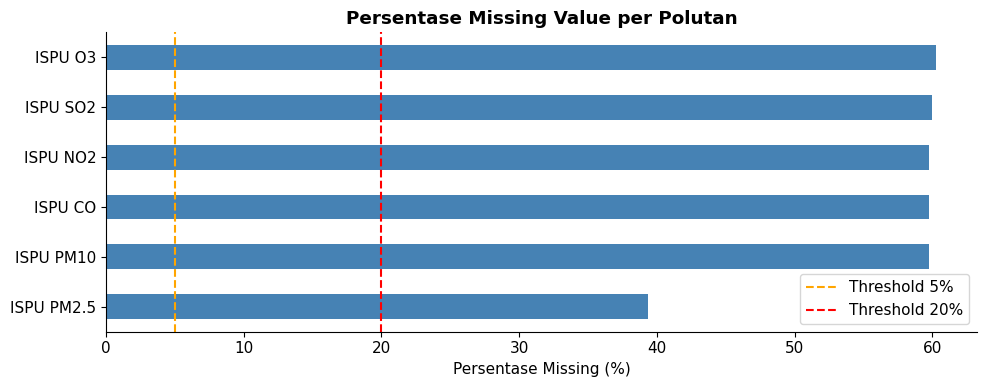

In [10]:
import os
os.makedirs('outputs', exist_ok=True)

# Visualisasi missing value with missingno
if MISSINGNO_AVAILABLE and df_polusi.isnull().sum().sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Matrix plot, ini untuk show pola missing secara visual
    plt.subplot(1, 2, 1)
    msno.matrix(df_polusi[POLLUTANTS], ax=plt.gca(), sparkline=False, fontsize=11)
    plt.title('Pola Missing Value Data Polusi\n', fontsize=12, fontweight='bold')
    
    # Bar chart, ini untuk persentase ketersediaan data
    plt.subplot(1, 2, 2)
    msno.bar(df_polusi[POLLUTANTS], ax=plt.gca(), fontsize=11, color='steelblue')
    plt.title('Persentase Data Tersedia per Kolom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('outputs/missing_value_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    
    # Fallback: bar chart manual
    missing_pct = df_polusi[POLLUTANTS].isnull().mean() * 100
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_pct.sort_values(ascending=True).plot(kind='barh', color='steelblue', ax=ax)
    ax.set_xlabel('Persentase Missing (%)')
    ax.set_title('Persentase Missing Value per Polutan', fontweight='bold')
    ax.axvline(x=5, color='orange', linestyle='--', label='Threshold 5%')
    ax.axvline(x=20, color='red', linestyle='--', label='Threshold 20%')
    ax.legend()
    plt.tight_layout()
    plt.savefig('outputs/missing_value_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
# Analisis missing value yang berkorelasi (muncul bersamaan)
if MISSINGNO_AVAILABLE and df_polusi[POLLUTANTS].isnull().sum().sum() > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    msno.heatmap(df_polusi[POLLUTANTS], ax=ax, fontsize=11)
    ax.set_title('Korelasi Pola Missing antar Kolom Polutan\n', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/missing_value_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Nilai mendekati 1: kedua sensor ispu sering mati bersamaan')
    print('Nilai mendekati -1: jika satu missing, yang lain justru ada data → pola bergantian')
    print('Nilai 0: pola missing tidak terkait')

MISSING VALUE PER LOKASI (%)


,ISPU PM10,ISPU PM2.5,ISPU SO2,ISPU CO,ISPU O3,ISPU NO2
station,,,,,,
bundaran hi,40.260,40.260,40.260,40.260,40.260,40.260
jagakarsa,40.260,40.260,40.260,40.260,40.260,40.260
jakarta gbk,76.750,76.800,78.350,76.750,80.590,77.050
kebun jeruk,40.260,40.260,40.260,40.260,40.260,40.260
kelapa gading,40.260,40.260,40.260,40.260,40.260,40.260
lubang buaya,40.260,40.260,40.260,40.260,40.260,40.260
us embassy 1,100.000,10.970,100.000,100.000,100.000,100.000
us embassy 2,100.000,25.780,100.000,100.000,100.000,100.000


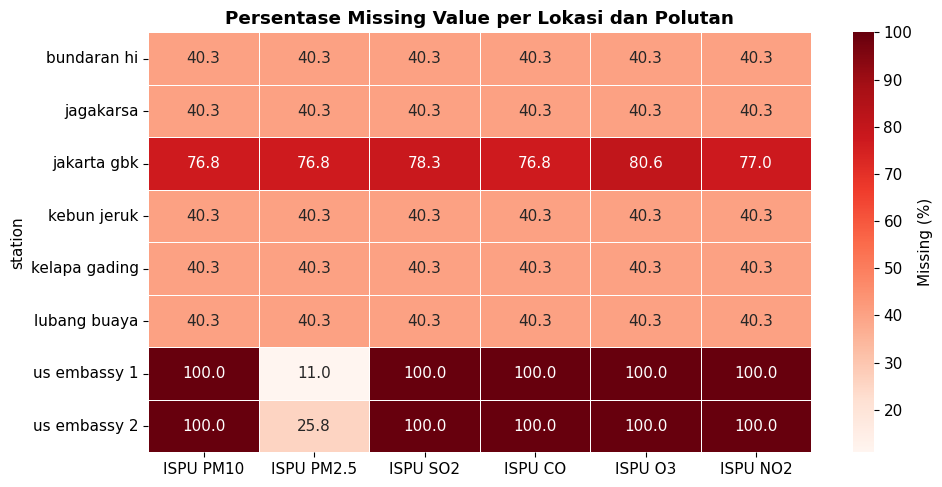

In [12]:
# Analisis missing value per lokasi
KOLOM_LOKASI = 'station' 

if KOLOM_LOKASI in df_polusi.columns:
    missing_per_lokasi = df_polusi.groupby(KOLOM_LOKASI)[POLLUTANTS].apply(
        lambda x: (x.isnull().sum() / len(x) * 100).round(2)
    )
    print('MISSING VALUE PER LOKASI (%)')
    display(missing_per_lokasi)
    
    # Heatmap missing per lokasi
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(missing_per_lokasi, annot=True, fmt='.1f', cmap='Reds', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Missing (%)'})
    ax.set_title('Persentase Missing Value per Lokasi dan Polutan', fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/missing_per_lokasi.png', dpi=150, bbox_inches='tight')
    plt.show()


In [13]:
# PENANGANAN MISSING VALUE

df_bersih = df_polusi.copy()

# Hapus kolom dengan missing > 50%
threshold_drop = 50
kolom_drop = [col for col in POLLUTANTS 
               if df_polusi[col].isnull().mean() * 100 > threshold_drop]
if kolom_drop:
    print(f'Kolom yang dihapus (missing > {threshold_drop}%): {kolom_drop}')
    df_bersih = df_bersih.drop(columns=kolom_drop)
    POLLUTANTS_AKTIF = [col for col in POLLUTANTS if col not in kolom_drop]
else:
    print('Tidak ada kolom dengan missing > 50%')
    POLLUTANTS_AKTIF = POLLUTANTS.copy()

# Sort berdasarkan datetime (untuk forward fill)
if 'datetime' in df_bersih.columns:
    df_bersih = df_bersih.sort_values('datetime').reset_index(drop=True)

# Forward fill → untuk gap kecil pada data time series
# mengisi dengan nilai terdekat sebelumnya
df_bersih[POLLUTANTS_AKTIF] = df_bersih[POLLUTANTS_AKTIF].fillna(method='ffill', limit=3)

# Backward fill → untuk data yang masih missing di awal
df_bersih[POLLUTANTS_AKTIF] = df_bersih[POLLUTANTS_AKTIF].fillna(method='bfill', limit=3)

# Untuk missing yang tersisa, pake median per lokasi
if KOLOM_LOKASI in df_bersih.columns:
    for col in POLLUTANTS_AKTIF:
        df_bersih[col] = df_bersih.groupby(KOLOM_LOKASI)[col].transform(
            lambda x: x.fillna(x.median())
        )
else:
    # Jika tidak ada kolom lokasi,pake median global
    for col in POLLUTANTS_AKTIF:
        df_bersih[col] = df_bersih[col].fillna(df_bersih[col].median())

# Cek hasil
sisa_missing = df_bersih[POLLUTANTS_AKTIF].isnull().sum().sum()
print(f'\nHASIL SETELAH PENANGANAN MISSING VALUE')
print(f'Missing sebelum : {df_polusi[POLLUTANTS].isnull().sum().sum():,}')
print(f'Missing sesudah : {sisa_missing:,}')
print(f'Data yang diperbaiki: {df_polusi[POLLUTANTS].isnull().sum().sum() - sisa_missing:,} sel')

Kolom yang dihapus (missing > 50%): ['ISPU PM10', 'ISPU SO2', 'ISPU CO', 'ISPU O3', 'ISPU NO2']


TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

---
## Distribusi Data (Histogram & Boxplot)

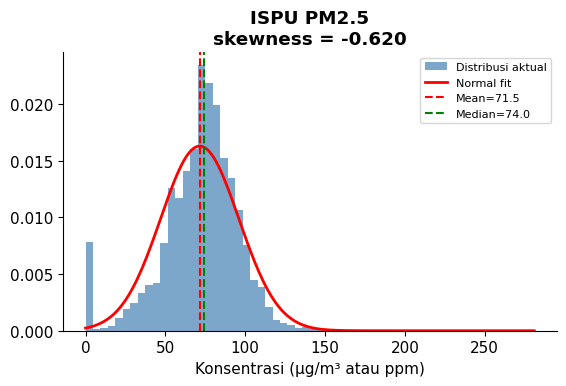

Jika mean >> median → distribusi right-skewed → pertimbangkan log transform
Kurva distribusi jauh dari kurva normal → data tidak terdistribusi normal
Distribusi bimodal (2 puncak) → mungkin ada 2 kondisi berbeda (mis. musim hujan vs kemarau)


In [ ]:
# Histogram distribusi tiap polutan + kurva normal
n_cols = 3
n_rows = (len(POLLUTANTS_AKTIF) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(POLLUTANTS_AKTIF):
    data = df_bersih[col].dropna()
    ax = axes[i]
    
    # Histogram
    ax.hist(data, bins=60, color='steelblue', alpha=0.7, density=True, label='Distribusi aktual')
    
    # Kurva normal fit
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')
    
    # Garis mean dan median
    ax.axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mu:.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median={data.median():.1f}')
    
    skew_val = data.skew()
    ax.set_title(f'{col}\nskewness = {skew_val:.3f}', fontweight='bold')
    ax.set_xlabel('Konsentrasi (µg/m³ atau ppm)')
    ax.legend(fontsize=8)

# Sembunyikan axes kosong
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/distribusi_polutan.png', dpi=150, bbox_inches='tight')
plt.show()

print('Jika mean >> median → distribusi right-skewed → pertimbangkan log transform')
print('Kurva distribusi jauh dari kurva normal → data tidak terdistribusi normal')
print('Distribusi bimodal (2 puncak) → mungkin ada 2 kondisi berbeda (mis. musim hujan vs kemarau)')

# garis merah = mean, garis hijau = median

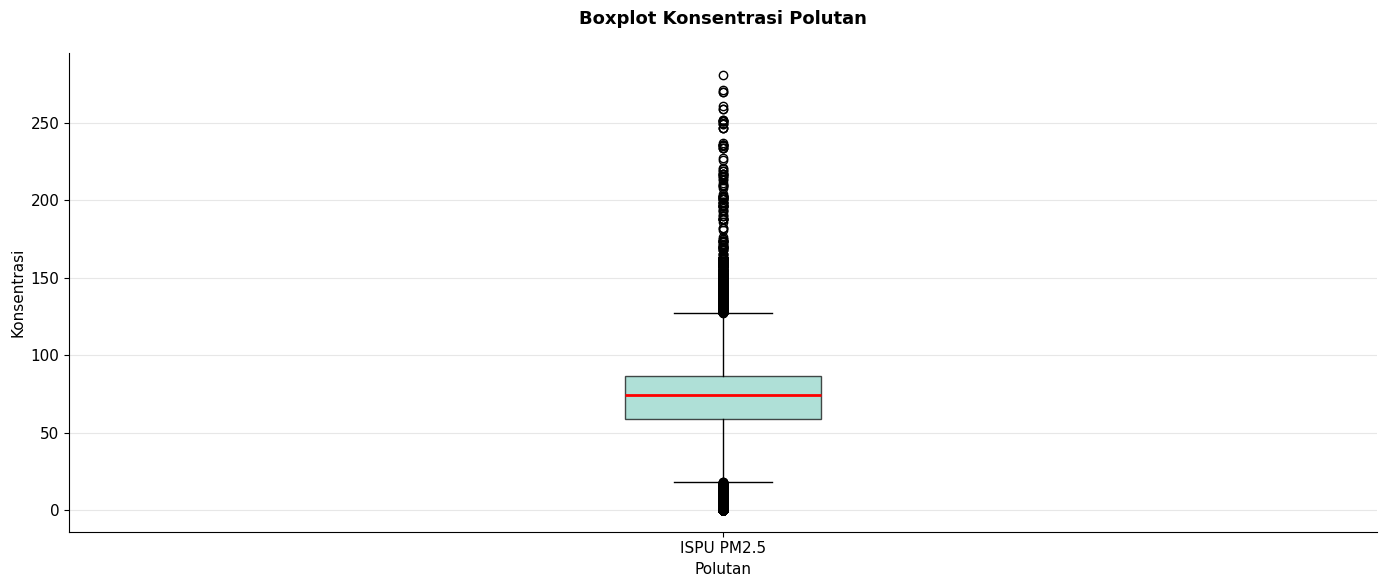

Garis merah dalam box = median
Box = rentang IQR (Q1 hingga Q3)
Whisker = 1.5 × IQR dari batas box
Titik di luar whisker = outlier


In [ ]:
# Boxplot per polutan mendeteksi outlier
fig, ax = plt.subplots(figsize=(14, 6))

data_box = [df_bersih[col].dropna().values for col in POLLUTANTS_AKTIF]
bp = ax.boxplot(data_box, labels=POLLUTANTS_AKTIF, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

colors = plt.cm.Set3(np.linspace(0, 1, len(POLLUTANTS_AKTIF)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Boxplot Konsentrasi Polutan\n', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Konsentrasi')
ax.set_xlabel('Polutan')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/boxplot_polutan.png', dpi=150, bbox_inches='tight')
plt.show()

print('Garis merah dalam box = median')
print('Box = rentang IQR (Q1 hingga Q3)')
print('Whisker = 1.5 × IQR dari batas box')
print('Titik di luar whisker = outlier')

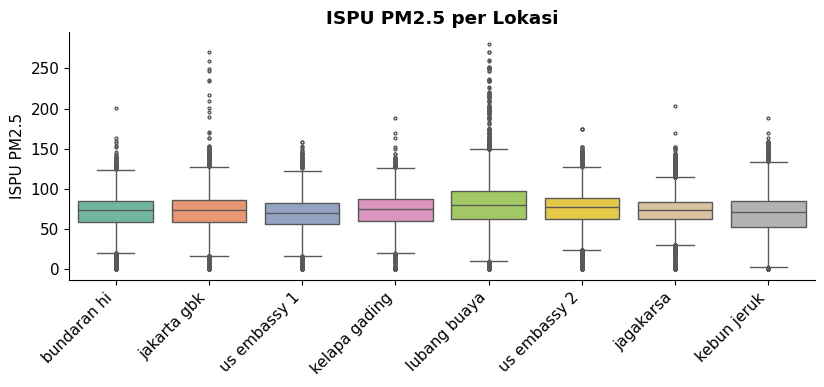

In [ ]:
# Boxplot per lokasi
if KOLOM_LOKASI in df_bersih.columns:
    n_cols = 2
    n_rows = (len(POLLUTANTS_AKTIF) + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(POLLUTANTS_AKTIF):
        sns.boxplot(data=df_bersih, x=KOLOM_LOKASI, y=col, ax=axes[i],
                    palette='Set2', fliersize=2)
        axes[i].set_title(f'{col} per Lokasi', fontweight='bold')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].set_xlabel('')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('outputs/boxplot_per_lokasi.png', dpi=150, bbox_inches='tight')
    plt.show()
    

---
## Analisis Pola Temporal

In [ ]:
# Pola PM2.5 per jam dalam sehari (rush hour effect)
if 'jam' in df_bersih.columns and 'PM2.5' in df_bersih.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Rata-rata per jam
    hourly = df_bersih.groupby('jam')[POLLUTANTS_AKTIF].mean()
    
    # Plot untuk polutan utama
    main_pollutants = [p for p in ['PM2.5', 'PM10', 'NO2'] if p in POLLUTANTS_AKTIF]
    hourly[main_pollutants].plot(ax=axes[0], marker='o', markersize=4, linewidth=2)
    axes[0].set_title('Pola Konsentrasi per Jam (Rata-rata)', fontweight='bold')
    axes[0].set_xlabel('Jam (0–23)')
    axes[0].set_ylabel('Konsentrasi (µg/m³)')
    axes[0].axvspan(6, 9, alpha=0.1, color='orange', label='Rush hour pagi')
    axes[0].axvspan(16, 20, alpha=0.1, color='red', label='Rush hour sore')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xticks(range(0, 24))
    
    # Heatmap jam vs hari
    pivot = df_bersih.pivot_table(values='PM2.5', index='jam', 
                                   columns='hari_minggu', aggfunc='mean')
    pivot.columns = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
    sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', fmt='.0f', annot=True, 
                linewidths=0.3, annot_kws={'size': 8})
    axes[1].set_title('Heatmap PM2.5 — Jam vs Hari dalam Seminggu', fontweight='bold')
    axes[1].set_ylabel('Jam')
    
    plt.tight_layout()
    plt.savefig('outputs/pola_temporal_jam.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Puncak di jam 7-9 & 16-19 → rush hour (kendaraan bermotor)')
    print('Puncak tengah malam (0-3) rendah → aktivitas manusia minimal')
    print('Hari kerja vs weekend berbeda → polusi lebih tinggi hari kerja (transportasi & industri)')

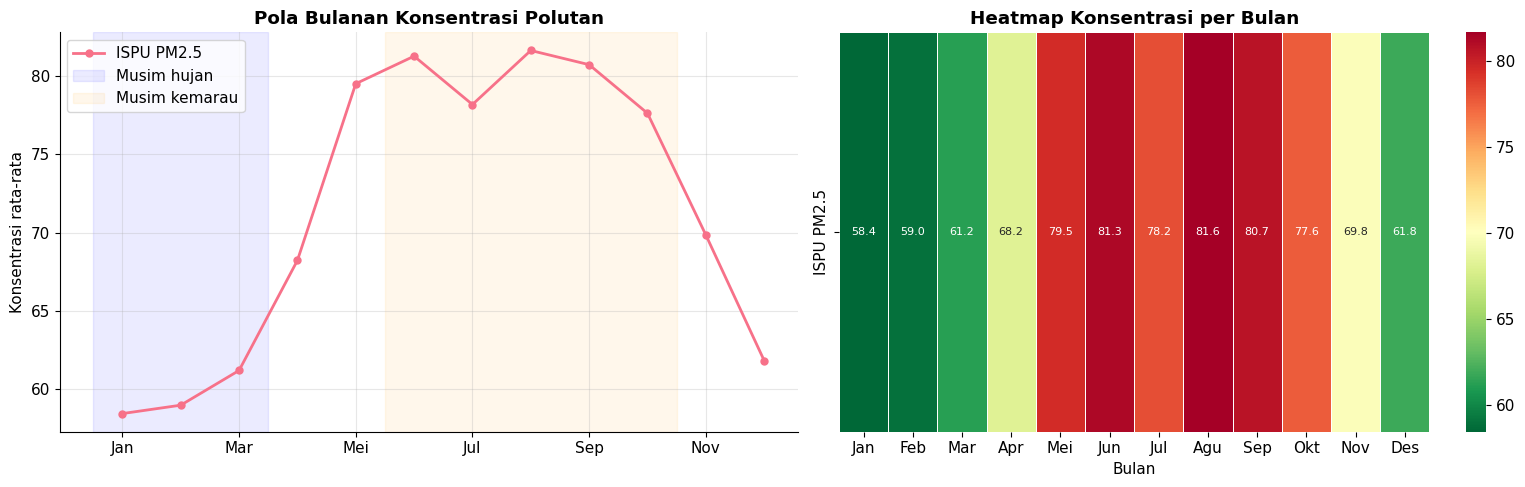

Musim kemarau (Jun-Okt): polusi cenderung lebih tinggi karena kurang hujan
Musim hujan (Nov-Mar): hujan membantu membersihkan udara (wet deposition)
Jika pola tidak jelas → faktor lain (industri, kebakaran)


In [ ]:
# Pola bulanan (musim hujan vs kemarau di Jakarta)
if 'bulan' in df_bersih.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    monthly = df_bersih.groupby('bulan')[POLLUTANTS_AKTIF].mean()
    monthly.index = ['Jan','Feb','Mar','Apr','Mei','Jun',
                     'Jul','Agu','Sep','Okt','Nov','Des']
    
    # Line plot
    monthly.plot(ax=axes[0], marker='o', markersize=5, linewidth=2)
    # Shading musim hujan Jakarta (sekitar Nov-Mar) dan kemarau (Mei-Okt)
    axes[0].axvspan(-0.5, 2.5, alpha=0.08, color='blue', label='Musim hujan')
    axes[0].axvspan(4.5, 9.5, alpha=0.08, color='orange', label='Musim kemarau')
    axes[0].set_title('Pola Bulanan Konsentrasi Polutan', fontweight='bold')
    axes[0].set_ylabel('Konsentrasi rata-rata')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Heatmap bulan vs polutan
    sns.heatmap(monthly.T, ax=axes[1], cmap='RdYlGn_r', annot=True, fmt='.1f',
                linewidths=0.5, annot_kws={'size': 8})
    axes[1].set_title('Heatmap Konsentrasi per Bulan', fontweight='bold')
    axes[1].set_xlabel('Bulan')
    
    plt.tight_layout()
    plt.savefig('outputs/pola_bulanan.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Musim kemarau (Jun-Okt): polusi cenderung lebih tinggi karena kurang hujan')
    print('Musim hujan (Nov-Mar): hujan membantu membersihkan udara (wet deposition)')
    print('Jika pola tidak jelas → faktor lain (industri, kebakaran)')

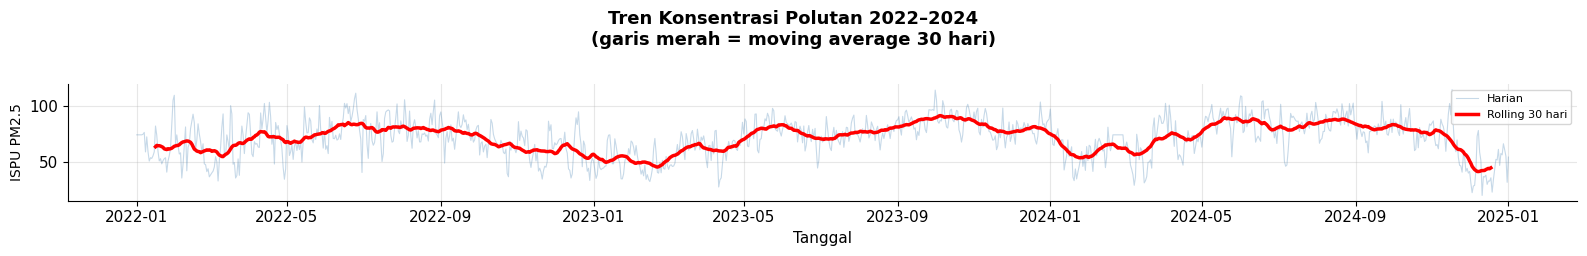

Spike yang tiba-tiba → kemungkinan event (kebakaran, bencana, industri)
Pola berulang setiap tahun → musiman yang kuat → perlu lag features tahunan


In [ ]:
# Tren jangka panjang 2022-2024
if 'datetime' in df_bersih.columns:
    
    # Resample ke harian untuk memperjelas tren
    df_daily = df_bersih.set_index('datetime')[POLLUTANTS_AKTIF].resample('D').mean()
    df_rolling = df_daily.rolling(window=30, center=True).mean()  # Rata-rata 30 hari
    
    fig, axes = plt.subplots(len(POLLUTANTS_AKTIF), 1, 
                              figsize=(16, len(POLLUTANTS_AKTIF) * 2.5), sharex=True)
    if len(POLLUTANTS_AKTIF) == 1:
        axes = [axes]
    
    for i, col in enumerate(POLLUTANTS_AKTIF):
        axes[i].plot(df_daily.index, df_daily[col], 
                     alpha=0.3, linewidth=0.8, color='steelblue', label='Harian')
        axes[i].plot(df_rolling.index, df_rolling[col], 
                     linewidth=2.5, color='red', label='Rolling 30 hari')
        axes[i].set_ylabel(col, fontsize=10)
        axes[i].grid(alpha=0.3)
        axes[i].legend(fontsize=8, loc='upper right')
    
    axes[-1].set_xlabel('Tanggal')
    plt.suptitle('Tren Konsentrasi Polutan 2022–2024\n(garis merah = moving average 30 hari)', 
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('outputs/tren_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Spike yang tiba-tiba → kemungkinan event (kebakaran, bencana, industri)')
    print('Pola berulang setiap tahun → musiman yang kuat → perlu lag features tahunan')

---
## Analisis Korelasi: Polutan vs Cuaca

In [ ]:
# Merge data polusi harian dengan data cuaca

if 'datetime' in df_bersih.columns:
    
    # Aggregate polusi ke harian (ini ngambil rata rata harian)
    df_polusi_daily = df_bersih.copy()
    df_polusi_daily['tanggal'] = pd.to_datetime(df_polusi_daily['datetime'].dt.date)
    df_polusi_daily = (
        df_polusi_daily
        .groupby(['tanggal', 'station'])[POLLUTANTS_AKTIF]
        .mean()
        .reset_index()
)    
    print(f'   Polusi tanggal range: {df_polusi_daily["tanggal"].min()} s/d {df_polusi_daily["tanggal"].max()}')
    print(f'   Polusi tanggal dtype: {df_polusi_daily["tanggal"].dtype}')
    
    # Siapkan data cuaca
    df_cuaca_merge = df_cuaca.copy()
    
    # Standardisasi nama kolom dan type
    if 'datetime' in df_cuaca_merge.columns:
        df_cuaca_merge['tanggal'] = pd.to_datetime(df_cuaca_merge['datetime'])
        print(f'\n  Data cuaca shape: {df_cuaca_merge.shape}')
        print(f'   Cuaca tanggal range: {df_cuaca_merge["tanggal"].min()} s/d {df_cuaca_merge["tanggal"].max()}')
        print(f'   Cuaca tanggal dtype: {df_cuaca_merge["tanggal"].dtype}')
    
    # Kolom cuaca numerik yang relevan
    CUACA_NUMERIK_LIST = ['tempmax', 'tempmin', 'temp', 'feelslike', 'dew', 'humidity',
                     'precip', 'precipprob', 'windgust', 'windspeed', 'winddir',
                     'sealevelpressure', 'cloudcover', 'visibility',
                     'solarradiation', 'solarenergy', 'uvindex']
    
    # Filter yang benar-benar ada di dataframe
    CUACA_NUMERIK = [col for col in CUACA_NUMERIK_LIST if col in df_cuaca_merge.columns]
    print(f'\n Kolom cuaca yang ditemukan: {len(CUACA_NUMERIK)} kolom → {CUACA_NUMERIK}')
    
    # Convert cuaca numeric columns
    for col in CUACA_NUMERIK:
        df_cuaca_merge[col] = pd.to_numeric(df_cuaca_merge[col], errors='coerce')
    
    # Merge dengan left join (polusi adalah master, cuaca adalah detail)
    df_gabung = pd.merge(
        df_polusi_daily,
        df_cuaca_merge[['tanggal', 'station'] + CUACA_NUMERIK],
        on=['tanggal', 'station'],
        how='left'
)
    
    print(f'   Shape setelah merge: {df_gabung.shape}')
    print(f'   Rows dengan cuaca data: {df_gabung[CUACA_NUMERIK[0]].notna().sum()} / {len(df_gabung)}')
    
    # Info final
    print(f'\n RINGKASAN MERGE:')
    print(f'   Total baris polusi daily: {len(df_polusi_daily)}')
    print(f'   Total baris cuaca: {len(df_cuaca_merge)}')
    print(f'   Total baris gabung: {len(df_gabung)}')
    print(f'   Baris dengan data cuaca lengkap: {df_gabung.dropna(subset=CUACA_NUMERIK, how='all').shape[0]}')
    
    display(df_gabung.head(20))
else:
    print('Kolom datetime tidak ditemukan di data polusi')


   Polusi tanggal range: 2022-01-01 00:00:00 s/d 2025-01-01 00:00:00
   Polusi tanggal dtype: datetime64[ns]

  Data cuaca shape: (8768, 35)
   Cuaca tanggal range: 2022-01-01 00:00:00 s/d 2024-12-31 00:00:00
   Cuaca tanggal dtype: datetime64[ns]

 Kolom cuaca yang ditemukan: 17 kolom → ['tempmax', 'tempmin', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']
   Shape setelah merge: (8776, 20)
   Rows dengan cuaca data: 8768 / 8776

 RINGKASAN MERGE:
   Total baris polusi daily: 8776
   Total baris cuaca: 8768
   Total baris gabung: 8776
   Baris dengan data cuaca lengkap: 8768


,tanggal,station,ISPU PM2.5,tempmax,tempmin,temp,feelslike,dew,humidity,precip,precipprob,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex
0,2022-01-01,bundaran hi,74.000,32.300,25.000,28.600,31.900,24.000,77.200,0.496,100.000,37.100,21.700,261.800,1009.600,50.800,6.700,249.200,20.600,9.000
1,2022-01-01,jagakarsa,73.000,31.800,25.000,28.300,31.200,23.800,77.800,0.502,100.000,37.100,21.800,257.900,1009.600,48.400,6.800,249.200,20.600,9.000
2,2022-01-01,jakarta gbk,73.000,32.100,25.000,28.500,31.800,24.000,77.500,0.507,100.000,37.100,21.600,261.300,1009.600,49.800,6.800,249.200,20.600,9.000
3,2022-01-01,kebun jeruk,71.000,31.700,25.000,28.300,31.600,24.100,79.300,0.645,100.000,37.100,21.000,261.200,1009.600,49.600,7.500,249.200,20.600,9.000
4,2022-01-01,kelapa gading,74.974,31.800,25.000,28.600,31.800,23.900,76.900,0.262,100.000,34.900,21.800,259.000,1009.600,50.100,6.700,255.000,21.000,9.000
5,2022-01-01,lubang buaya,80.000,32.000,25.000,28.500,31.700,23.800,76.800,0.451,100.000,34.900,22.300,253.800,1009.500,42.500,6.200,255.000,21.000,9.000
6,2022-01-01,us embassy 1,70.285,32.333,25.000,28.611,31.944,24.000,77.300,0.020,100.000,23.000,13.400,261.900,1009.600,50.900,4.200,249.200,20.600,9.000
7,2022-01-01,us embassy 2,77.250,31.900,25.000,28.500,31.700,24.000,77.700,0.529,100.000,37.100,21.600,260.600,1009.600,48.900,6.800,249.200,20.600,9.000
8,2022-01-02,bundaran hi,74.000,32.800,25.000,28.100,31.100,23.900,79.200,0.000,0.000,30.600,22.800,265.500,1009.200,49.300,6.800,220.200,19.000,7.000
9,2022-01-02,jagakarsa,73.000,32.800,25.000,27.900,30.300,23.700,79.200,0.009,100.000,30.600,23.200,256.700,1009.100,44.300,6.900,220.200,19.000,7.000


df_gabung shape: (8776, 20)
df_gabung columns: ['tanggal', 'station', 'ISPU PM2.5', 'tempmax', 'tempmin', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']
POLLUTANTS_AKTIF: ['ISPU PM2.5']
CUACA_NUMERIK: ['tempmax', 'tempmin', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']
Kolom untuk korelasi: ['ISPU PM2.5', 'tempmax', 'tempmin', 'temp', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex']
Total kolom: 18
Korelasi matrix shape: (18, 18)


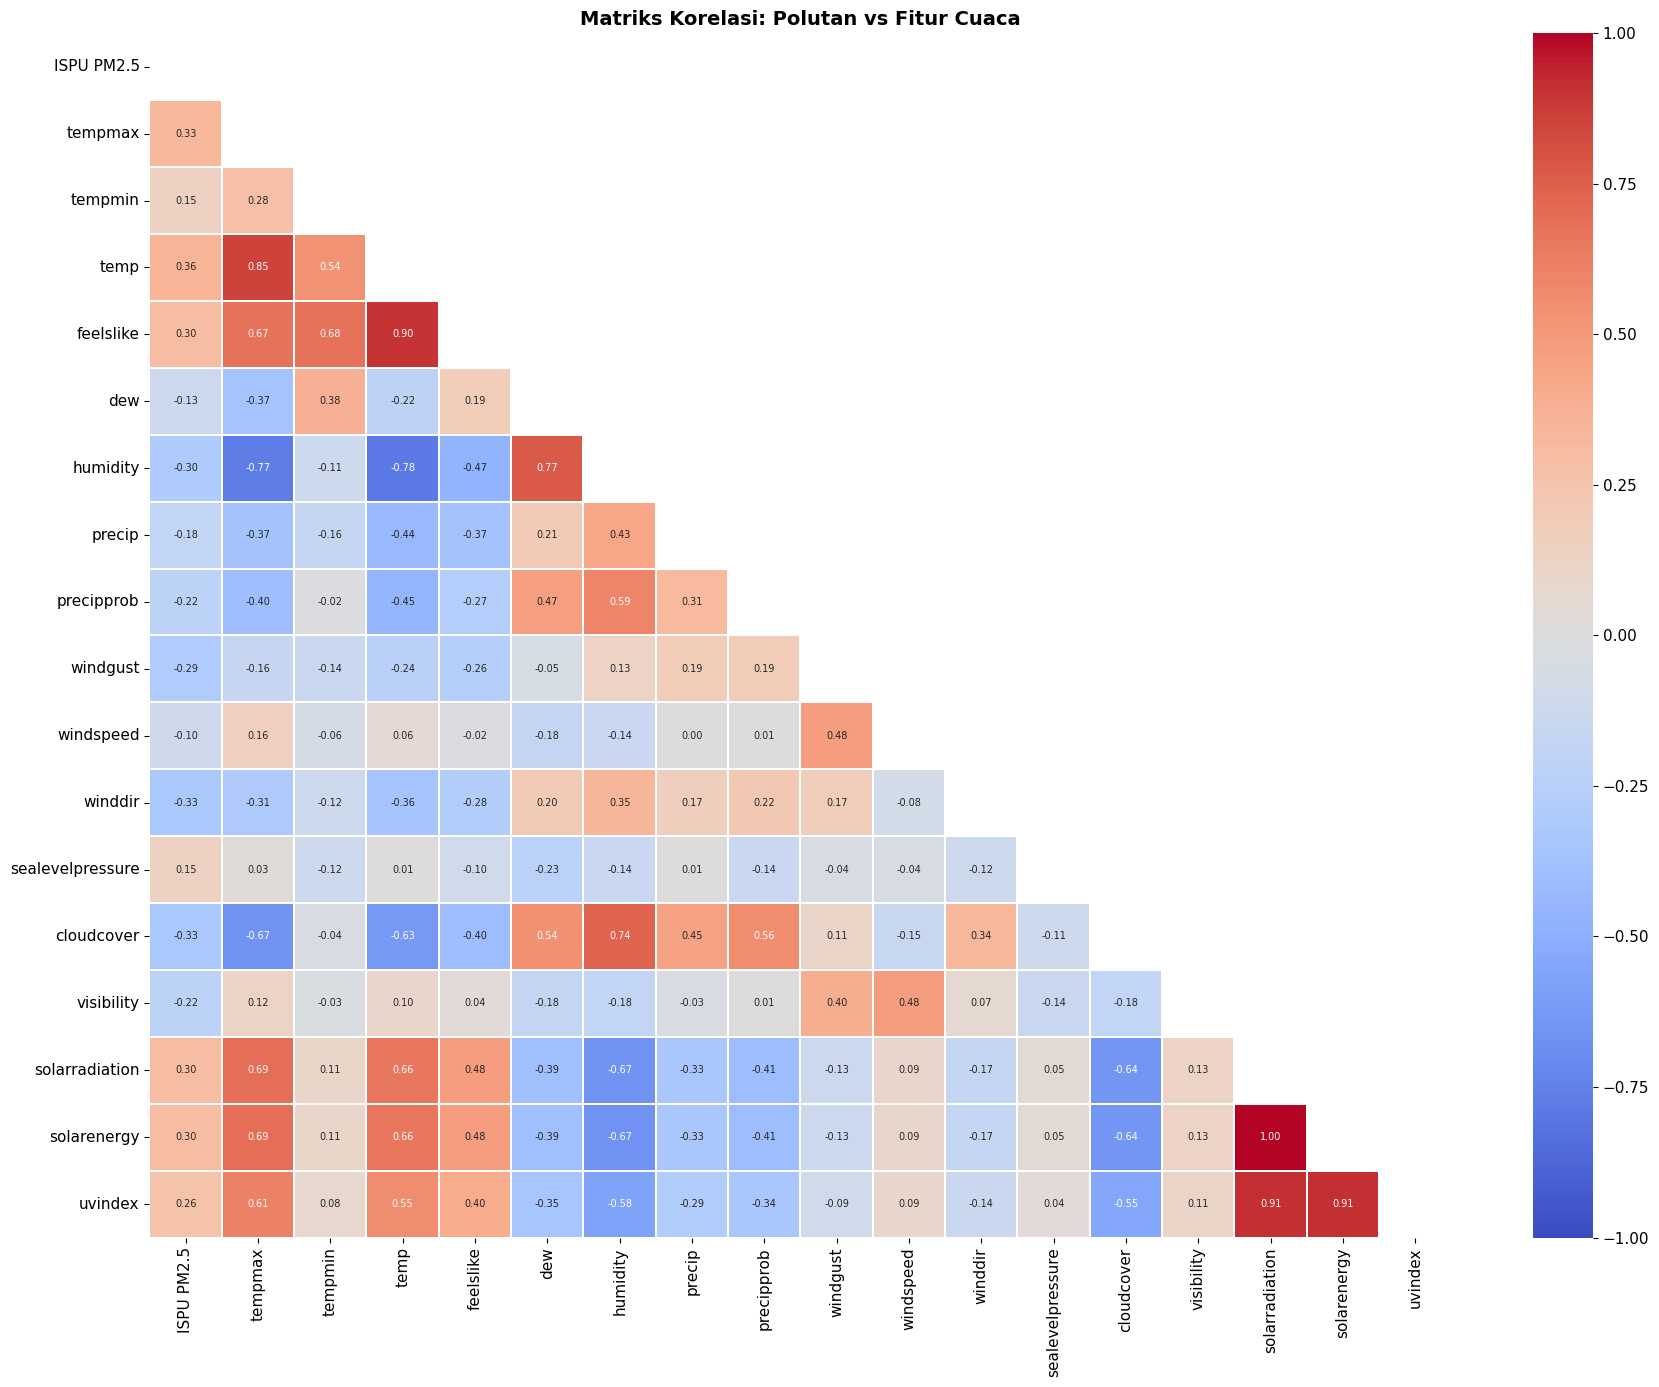


 TOP 5 KORELASI FITUR CUACA DENGAN TIAP POLUTAN

ISPU PM2.5:
   (+) temp                     : r = 0.358
   (+) tempmax                  : r = 0.334
   (-) cloudcover               : r = -0.327
   (-) winddir                  : r = -0.327
   (-) humidity                 : r = -0.303


In [ ]:
if 'df_gabung' in dir():
    print(f'df_gabung shape: {df_gabung.shape}')
    print(f'df_gabung columns: {list(df_gabung.columns)}')
    print(f'POLLUTANTS_AKTIF: {POLLUTANTS_AKTIF}')
    print(f'CUACA_NUMERIK: {CUACA_NUMERIK}')
    
    semua_kolom = POLLUTANTS_AKTIF + CUACA_NUMERIK
    semua_kolom = [col for col in semua_kolom if col in df_gabung.columns]
    print(f'Kolom untuk korelasi: {semua_kolom}')
    print(f'Total kolom: {len(semua_kolom)}')
    
    if len(semua_kolom) > 1:
        corr_matrix = df_gabung[semua_kolom].corr()
        print(f'Korelasi matrix shape: {corr_matrix.shape}')
        
        fig, ax = plt.subplots(figsize=(18, 14))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, ax=ax, linewidths=0.3, annot_kws={'size': 7},
                    vmin=-1, vmax=1)
        
        ax.set_title('Matriks Korelasi: Polutan vs Fitur Cuaca', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('outputs/korelasi_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Tampilkan korelasi teratas dengan polutan target
        print('\n TOP 5 KORELASI FITUR CUACA DENGAN TIAP POLUTAN')
        for pol in POLLUTANTS_AKTIF:
            if pol in corr_matrix.columns:
                top_corr = corr_matrix[pol].drop(POLLUTANTS_AKTIF, errors='ignore').abs().sort_values(ascending=False).head(5)
                print(f'\n{pol}:')
                for feat, val in top_corr.items():
                    arah = '(+)' if corr_matrix[pol][feat] > 0 else '(-)'
                    print(f'   {arah} {feat:25s}: r = {corr_matrix[pol][feat]:.3f}')

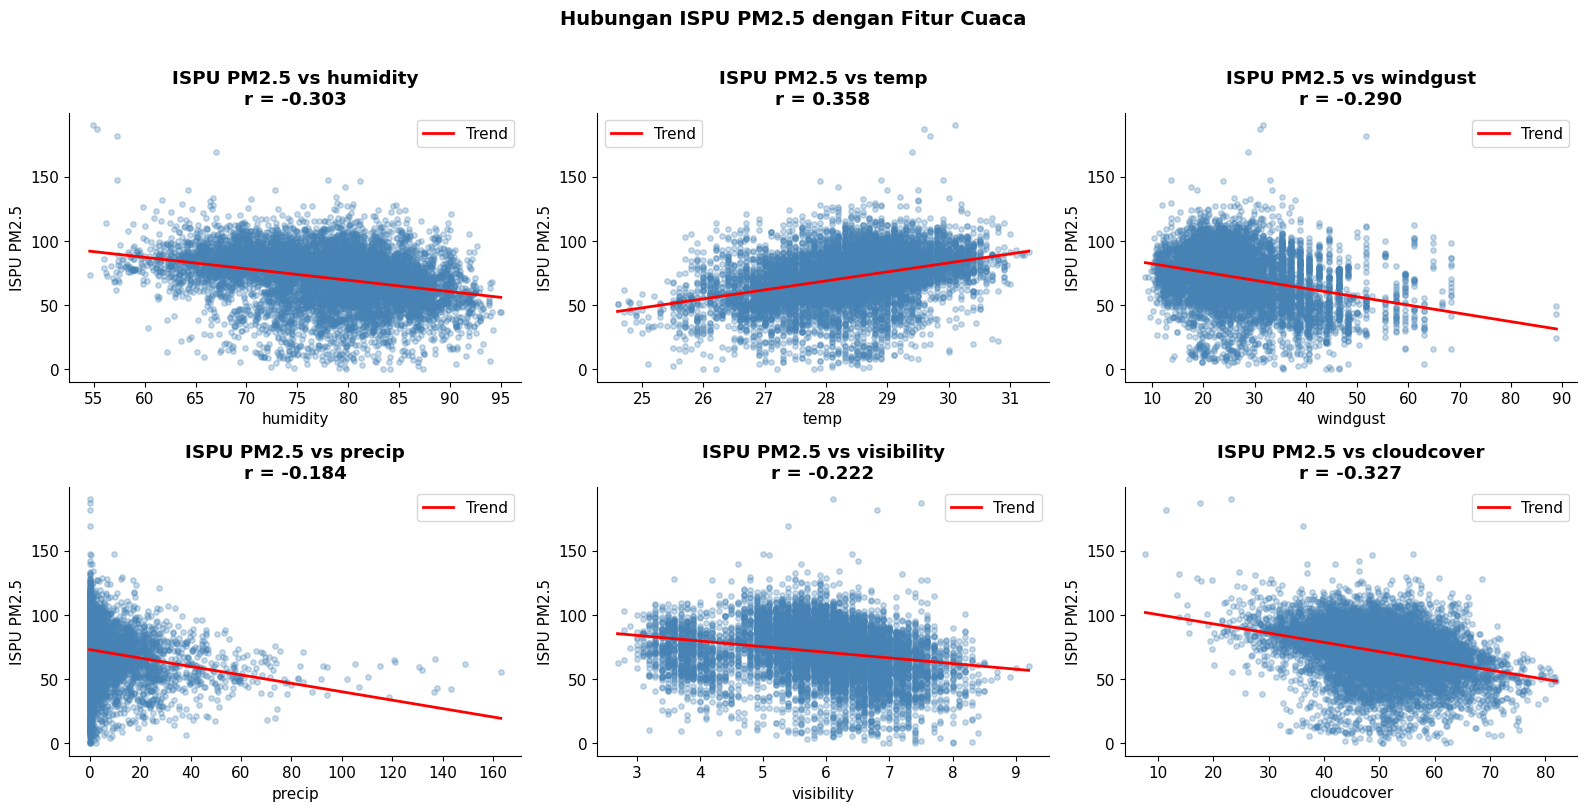

In [ ]:
# Scatter plot: PM2.5 vs beberapa fitur cuaca
if 'df_gabung' in dir():
    fitur_plot = [f for f in ['humidity', 'temp', 'windgust', 'precip', 'visibility', 'cloudcover']
                  if f in df_gabung.columns]
    target = 'PM2.5' if 'PM2.5' in df_gabung.columns else ('ISPU PM2.5' if 'ISPU PM2.5' in df_gabung.columns else POLLUTANTS_AKTIF[0])
    
    n_cols = 3
    n_rows = (len(fitur_plot) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten()
    
    for i, fitur in enumerate(fitur_plot):
        ax = axes[i]
        
        # Drop NaN untuk plot scatter
        valid_idx = (df_gabung[fitur].notna()) & (df_gabung[target].notna())
        x_data = df_gabung.loc[valid_idx, fitur].values
        y_data = df_gabung.loc[valid_idx, target].values
        
        if len(x_data) > 1:
            ax.scatter(x_data, y_data, alpha=0.3, s=15, color='steelblue')
            
            # Trend line
            z = np.polyfit(x_data, y_data, 1)
            p = np.poly1d(z)
            x_range = np.linspace(x_data.min(), x_data.max(), 100)
            ax.plot(x_range, p(x_range), 'r-', linewidth=2, label='Trend')
            
            r = np.corrcoef(x_data, y_data)[0, 1]
            ax.set_title(f'{target} vs {fitur}\nr = {r:.3f}', fontweight='bold')
            ax.set_xlabel(fitur)
            ax.set_ylabel(target)
            ax.legend()
        else:
            ax.text(0.5, 0.5, f'Data {fitur} tidak cukup', ha='center', va='center')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Hubungan {target} dengan Fitur Cuaca', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('outputs/scatter_polusi_cuaca.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
df_cuaca.groupby('station')['temp'].describe()

,count,mean,std,min,25%,50%,75%,max
station,,,,,,,,
bundaran hi,1096.000,28.452,1.056,24.800,27.800,28.600,29.100,31.300
jagakarsa,1096.000,28.149,1.054,24.600,27.500,28.200,28.800,30.900
jakarta gbk,1096.000,28.404,1.049,24.800,27.700,28.500,29.100,31.200
kebun jeruk,1096.000,28.296,1.031,24.600,27.600,28.400,29.000,31.000
kelapa gading,1096.000,28.435,1.056,24.800,27.775,28.500,29.100,31.200
lubang buaya,1096.000,28.295,1.090,24.700,27.600,28.400,29.000,31.100
us embassy 1,1096.000,28.454,1.052,24.778,27.778,28.556,29.125,31.222
us embassy 2,1096.000,28.364,1.051,24.700,27.700,28.500,29.100,31.100


---
## Deteksi Outlier

In [ ]:
def analisis_outlier(df, kolom_list, metode='iqr'):
    """
    Menggunakan metode IQR atau Z-Score.
    
    Catatan: Untuk data polusi, outlier TIDAK selalu berarti error.
    Bisa jadi event seperti bencana, atau kondisi cuaca ekstrem.
    """
    hasil = []
    
    for col in kolom_list:
        data = df[col].dropna()
        
        if metode == 'iqr':
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            batas_bawah = Q1 - 1.5 * IQR
            batas_atas  = Q3 + 1.5 * IQR
        elif metode == 'zscore':
            batas_bawah = data.mean() - 3 * data.std()
            batas_atas  = data.mean() + 3 * data.std()
        
        n_outlier_bawah = (data < batas_bawah).sum()
        n_outlier_atas  = (data > batas_atas).sum()
        n_outlier_total = n_outlier_bawah + n_outlier_atas
        
        hasil.append({
            'Polutan': col,
            'Total Data': len(data),
            'Batas Bawah': round(batas_bawah, 3),
            'Batas Atas': round(batas_atas, 3),
            'Outlier Bawah': n_outlier_bawah,
            'Outlier Atas': n_outlier_atas,
            'Total Outlier': n_outlier_total,
            'Pct Outlier (%)': round(n_outlier_total / len(data) * 100, 2)
        })
    
    return pd.DataFrame(hasil).set_index('Polutan')


print('DETEKSI OUTLIER - METODE IQR (1.5×IQR)')
outlier_iqr = analisis_outlier(df_bersih, POLLUTANTS_AKTIF, 'iqr')
display(outlier_iqr)

print('\nDETEKSI OUTLIER - METODE Z-SCORE (±3σ)')
outlier_zscore = analisis_outlier(df_bersih, POLLUTANTS_AKTIF, 'zscore')
display(outlier_zscore)

DETEKSI OUTLIER - METODE IQR (1.5×IQR)


,Total Data,Batas Bawah,Batas Atas,Outlier Bawah,Outlier Atas,Total Outlier,Pct Outlier (%)
Polutan,,,,,,,
ISPU PM2.5,210624,17.893,127.511,8300,1576,9876,4.690



DETEKSI OUTLIER - METODE Z-SCORE (±3σ)


,Total Data,Batas Bawah,Batas Atas,Outlier Bawah,Outlier Atas,Total Outlier,Pct Outlier (%)
Polutan,,,,,,,
ISPU PM2.5,210624,-2.030,145.012,0,343,343,0.160


In [ ]:
# Tandai outlier dengan flag 
df_flagged = df_bersih.copy()

for col in POLLUTANTS_AKTIF:
    Q1 = df_flagged[col].quantile(0.25)
    Q3 = df_flagged[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_flagged[f'{col}_is_outlier'] = ((df_flagged[col] < lower) | (df_flagged[col] > upper)).astype(int)

print(f'Flag outlier ditambahkan untuk {len(POLLUTANTS_AKTIF)} polutan:')
print(f'   {POLLUTANTS_AKTIF}')


if 'datetime' in df_flagged.columns and len(POLLUTANTS_AKTIF) > 0:
    target_col = POLLUTANTS_AKTIF[0]  # Ambil polutan pertama (ISPU PM2.5)
    outlier_flag_col = f'{target_col}_is_outlier'
    
    if outlier_flag_col in df_flagged.columns:
        outlier_dates = df_flagged[df_flagged[outlier_flag_col] == 1]['datetime']
        print(f'\n Analisis Outlier untuk {target_col}:')
        print(f'   Total outlier: {len(outlier_dates)} kejadian')
        print(f'   Persentase: {len(outlier_dates) / len(df_flagged) * 100:.2f}%')
        
        if len(outlier_dates) > 0:
            print(f'\n   Top 10 Tanggal dengan Outlier:')
            top_dates = outlier_dates.dt.date.value_counts().head(10)
            for date, count in top_dates.items():
                print(f'      {date}: {count} jam')
            
        else:
            print(f'Tidak ada outlier terdeteksi untuk {target_col}')
    else:
        print(f'Kolom {outlier_flag_col} tidak ditemukan')
else:
    print('Kolom datetime atau polutan tidak ditemukan')


Flag outlier ditambahkan untuk 1 polutan:
   ['ISPU PM2.5']

 Analisis Outlier untuk ISPU PM2.5:
   Total outlier: 9876 kejadian
   Persentase: 4.69%

   Top 10 Tanggal dengan Outlier:
      2024-11-17: 94 jam
      2022-06-30: 93 jam
      2023-07-19: 68 jam
      2024-12-11: 68 jam
      2023-07-23: 66 jam
      2023-10-23: 64 jam
      2022-07-02: 64 jam
      2022-07-05: 62 jam
      2024-12-03: 60 jam
      2023-07-30: 59 jam


---
## Save EDA

In [ ]:
import os
os.makedirs('outputs', exist_ok=True)
os.makedirs('data/interim', exist_ok=True)

df_flagged.to_csv('data/interim/data_eda_bersih.csv', index=False)

missing_polusi.to_csv('outputs/ringkasan_missing_polusi.csv')

outlier_iqr.to_csv('outputs/ringkasan_outlier.csv')

print('   data/interim/data_eda_bersih.csv')
print('   outputs/ringkasan_missing_polusi.csv')
print('   outputs/ringkasan_outlier.csv')
print('   outputs/*.png ')

   data/interim/data_eda_bersih.csv
   outputs/ringkasan_missing_polusi.csv
   outputs/ringkasan_outlier.csv
   outputs/*.png 
